In [19]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

print('Libraries loaded!')

Libraries loaded!


In [20]:
# Mount Google Drive and load dataset
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DailyDelhiClimateTrain.csv')
print('Shape:', df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (1462, 5)


In [21]:
# Normalize data
data = df['meantemp'].values.reshape(-1, 1)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

print('Data normalized!')

Data normalized!


In [22]:
# Create sliding window: last 7 days -> next day
def create_sequences(data, window=7):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, window=7)
print('X shape:', X.shape)

X shape: (1455, 7, 1)


In [23]:
# Split into train / validation / test
n = len(X)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:], y[val_end:]

print('Train:', len(X_train), '| Val:', len(X_val), '| Test:', len(X_test))

Train: 1018 | Val: 218 | Test: 219


In [24]:
# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

print('Tensors ready!')

Tensors ready!


In [25]:
# Define Simple RNN model (baseline)
class SimpleRNN(nn.Module):
    def __init__(self):
        super(SimpleRNN, self).__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=32, batch_first=True)
        self.fc  = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

In [26]:
# Define LSTM model
class LSTMModel(nn.Module):
    def __init__(self):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=32, batch_first=True)
        self.fc   = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

In [27]:
# Define GRU model
class GRUModel(nn.Module):
    def __init__(self):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size=1, hidden_size=32, batch_first=True)
        self.fc  = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out

In [28]:
# Function to train any model
def train_model(model, epochs=50):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    train_losses = []
    val_losses   = []

    for epoch in range(epochs):
        # Training step
        model.train()
        pred_train = model(X_train_t)
        loss_train = criterion(pred_train, y_train_t)
        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()

        # Validation step
        model.eval()
        with torch.no_grad():
            pred_val = model(X_val_t)
            loss_val = criterion(pred_val, y_val_t)

        train_losses.append(loss_train.item())
        val_losses.append(loss_val.item())

        if (epoch+1) % 10 == 0:
            print(f'Epoch {epoch+1}/{epochs} | Train: {loss_train.item():.4f} | Val: {loss_val.item():.4f}')

    return train_losses, val_losses

In [29]:
# Function to evaluate any model
def evaluate_model(model, name):
    model.eval()
    with torch.no_grad():
        pred_test = model(X_test_t).numpy()

    pred_original = scaler.inverse_transform(pred_test)
    y_original    = scaler.inverse_transform(y_test)

    mae  = mean_absolute_error(y_original, pred_original)
    rmse = np.sqrt(mean_squared_error(y_original, pred_original))

    print(f'{name} | MAE: {mae:.2f} | RMSE: {rmse:.2f}')
    return mae, rmse, pred_original

In [30]:
# Train Simple RNN
print('Simple RNN ')
rnn_model = SimpleRNN()
rnn_train_losses, rnn_val_losses = train_model(rnn_model)

Simple RNN 
Epoch 10/50 | Train: 0.0513 | Val: 0.0719
Epoch 20/50 | Train: 0.0375 | Val: 0.0413
Epoch 30/50 | Train: 0.0253 | Val: 0.0317
Epoch 40/50 | Train: 0.0101 | Val: 0.0095
Epoch 50/50 | Train: 0.0060 | Val: 0.0059


In [31]:
# Train LSTM
print(' LSTM ')
lstm_model = LSTMModel()
lstm_train_losses, lstm_val_losses = train_model(lstm_model)

 LSTM 
Epoch 10/50 | Train: 0.3145 | Val: 0.2412
Epoch 20/50 | Train: 0.2118 | Val: 0.1558
Epoch 30/50 | Train: 0.1046 | Val: 0.0721
Epoch 40/50 | Train: 0.0311 | Val: 0.0381
Epoch 50/50 | Train: 0.0379 | Val: 0.0519


In [32]:
# Train GRU
print('GRU ')
gru_model = GRUModel()
gru_train_losses, gru_val_losses = train_model(gru_model)

GRU 
Epoch 10/50 | Train: 0.3892 | Val: 0.2992
Epoch 20/50 | Train: 0.2227 | Val: 0.1612
Epoch 30/50 | Train: 0.0835 | Val: 0.0565
Epoch 40/50 | Train: 0.0283 | Val: 0.0410
Epoch 50/50 | Train: 0.0332 | Val: 0.0453


In [33]:
# Evaluate all models
print('Results')
rnn_mae,  rnn_rmse,  rnn_pred  = evaluate_model(rnn_model,  'Simple RNN')
lstm_mae, lstm_rmse, lstm_pred = evaluate_model(lstm_model, 'LSTM')
gru_mae,  gru_rmse,  gru_pred  = evaluate_model(gru_model,  'GRU')

Results
Simple RNN | MAE: 1.65 | RMSE: 2.14
LSTM | MAE: 3.48 | RMSE: 4.64
GRU | MAE: 3.32 | RMSE: 4.37


In [34]:
# Print comparison table
print('\n Comparison Table ')
print(f'{"Model":<12} {"MAE":>8} {"RMSE":>8}')
print('-' * 30)
print(f'{"Simple RNN":<12} {rnn_mae:>8.2f} {rnn_rmse:>8.2f}')
print(f'{"LSTM":<12} {lstm_mae:>8.2f} {lstm_rmse:>8.2f}')
print(f'{"GRU":<12} {gru_mae:>8.2f} {gru_rmse:>8.2f}')


 Comparison Table 
Model             MAE     RMSE
------------------------------
Simple RNN       1.65     2.14
LSTM             3.48     4.64
GRU              3.32     4.37


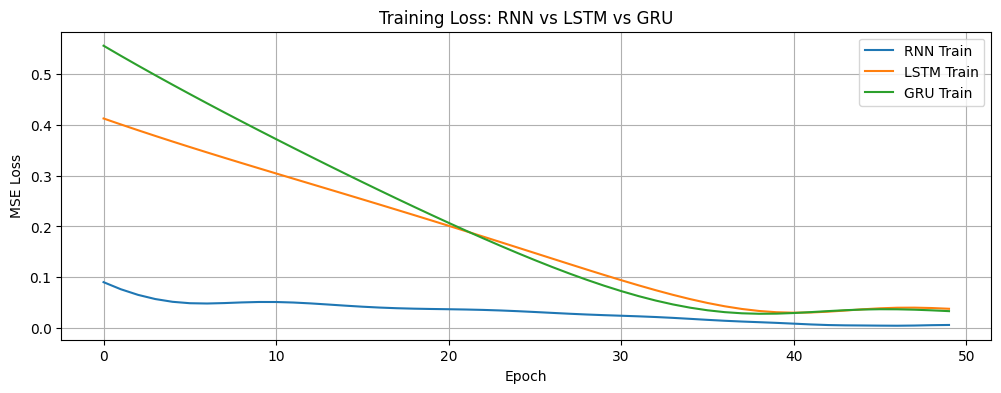

In [35]:
# Plot loss curves for all models
plt.figure(figsize=(12, 4))

plt.plot(rnn_train_losses,  label='RNN Train')
plt.plot(lstm_train_losses, label='LSTM Train')
plt.plot(gru_train_losses,  label='GRU Train')

plt.title('Training Loss: RNN vs LSTM vs GRU')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_comparison.png')
plt.show()

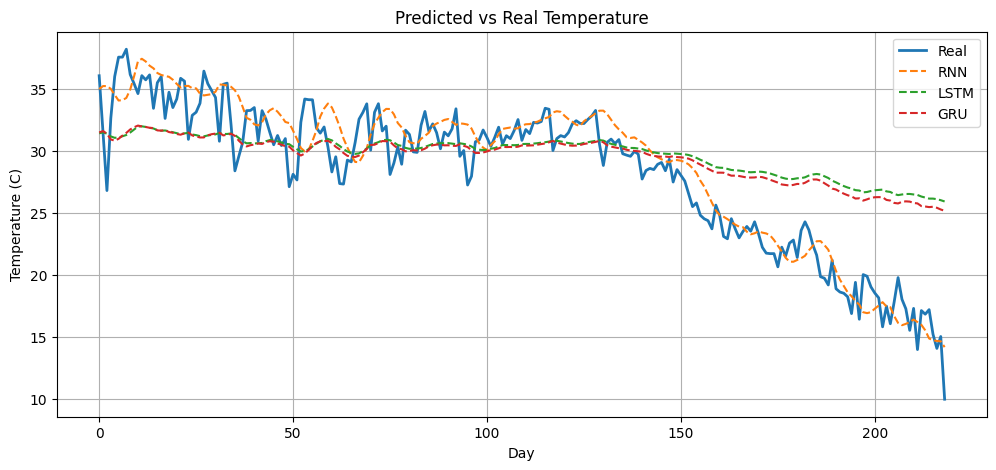

In [36]:
# Plot predictions vs real for all models
y_original = scaler.inverse_transform(y_test)

plt.figure(figsize=(12, 5))
plt.plot(y_original,  label='Real',       linewidth=2)
plt.plot(rnn_pred,    label='RNN',         linestyle='--')
plt.plot(lstm_pred,   label='LSTM',        linestyle='--')
plt.plot(gru_pred,    label='GRU',         linestyle='--')

plt.title('Predicted vs Real Temperature')
plt.xlabel('Day')
plt.ylabel('Temperature (C)')
plt.legend()
plt.grid(True)
plt.savefig('predictions_comparison.png')
plt.show()